In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

from sklearn.feature_selection import VarianceThreshold
from sklearn.manifold import TSNE

In [4]:
min_max_data = pd.read_csv("full_min_max_data.csv")
tsne_results = pd.read_csv("tsne_data.csv")

In [5]:
cols_to_factor = ['credit.policy', 'not.fully.paid', 'purpose']
for col in cols_to_factor:
    min_max_data[col] = min_max_data[col].astype('category')
print(min_max_data.dtypes)

dti                   float64
fico                  float64
days.with.cr.line     float64
revol.bal             float64
revol.util            float64
inq.last.6mths        float64
delinq.2yrs           float64
pub.rec               float64
annual.inc            float64
credit.policy        category
purpose              category
not.fully.paid       category
dtype: object


# Klasterizavimas ant pilnų orginalių duomenų

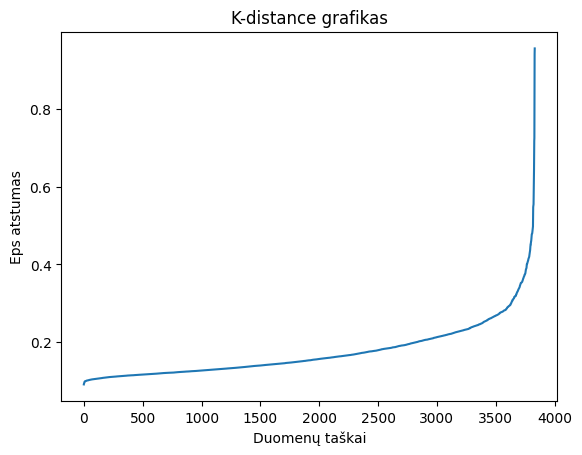

In [6]:
neighbors = NearestNeighbors(n_neighbors=18)
neighbors_fit = neighbors.fit(min_max_data.select_dtypes(include=[np.number]))
distances, indices = neighbors_fit.kneighbors(min_max_data.select_dtypes(include=[np.number]))

distances = np.sort(distances[:, 17], axis=0)
plt.plot(distances)
plt.title('K-distance grafikas')
plt.xlabel('Duomenų taškai')
plt.ylabel('Eps atstumas')
plt.show()

In [7]:
dbscan = DBSCAN(eps=0.35, min_samples=18)
clusters = dbscan.fit_predict(min_max_data.select_dtypes(include=[np.number]))

dbscan_clusters = min_max_data.copy()
dbscan_clusters['cluster'] = clusters

print(dbscan_clusters['cluster'].value_counts())

cluster
 0    3800
-1      32
Name: count, dtype: int64


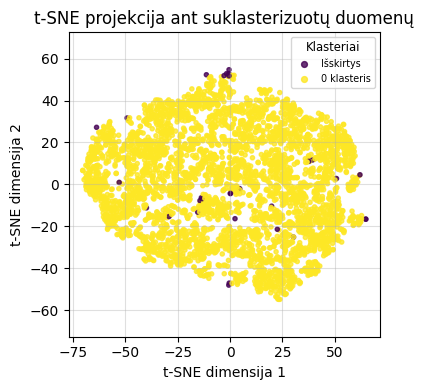

In [8]:
plt.figure(figsize=(4, 4))
scatter = plt.scatter(tsne_results.iloc[:, 0], 
                      tsne_results.iloc[:, 1], alpha=0.8, s=9, c=clusters)

plt.title("t-SNE projekcija ant suklasterizuotų duomenų")
plt.xlabel("t-SNE dimensija 1")
plt.ylabel("t-SNE dimensija 2")

handles, _ = scatter.legend_elements()
unique_labels = np.unique(clusters)
label_names = [f'{int(l)} klasteris' if l != -1 else 'Išskirtys' for l in unique_labels]
plt.legend(handles, label_names, 
           title="Klasteriai", 
           fontsize='x-small',
           title_fontsize='small',
           markerscale=0.7)
plt.grid(alpha=0.4)
plt.axis('equal')
plt.tight_layout()
plt.show()

# Klasterizavimas ant sumažintos dimensijos duomenų

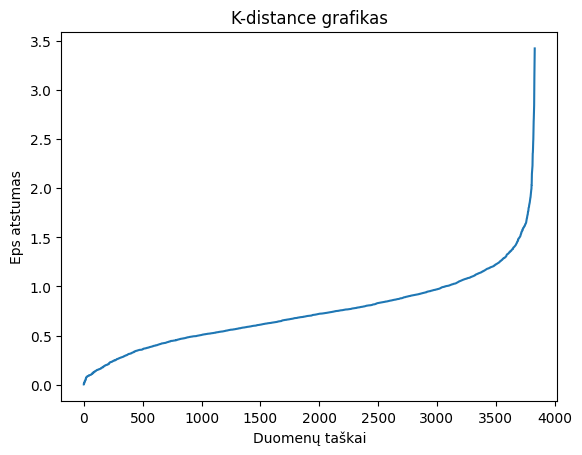

In [9]:
neighbors = NearestNeighbors(n_neighbors=8)
neighbors_fit = neighbors.fit(tsne_results)
distances, indices = neighbors_fit.kneighbors(tsne_results)

distances = np.sort(distances[:, 1], axis=0)
plt.plot(distances)
plt.title('K-distance grafikas')
plt.xlabel('Duomenų taškai')
plt.ylabel('Eps atstumas')
plt.show()

In [10]:
dbscan_tsne = DBSCAN(eps=1.25, min_samples=8)
clusters_tsne = dbscan_tsne.fit_predict(tsne_results)

dbscan_clusters_tsne = tsne_results.copy()
dbscan_clusters_tsne['cluster'] = clusters_tsne

print(dbscan_clusters_tsne['cluster'].value_counts())

cluster
-1    3770
 0      12
 1      10
 2       8
 6       8
 3       8
 5       8
 4       8
Name: count, dtype: int64


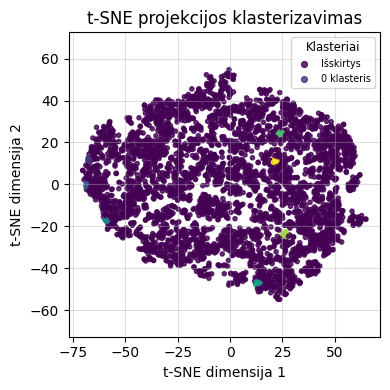

In [11]:
plt.figure(figsize=(4, 4))
scatter = plt.scatter(dbscan_clusters_tsne.iloc[:, 0], 
                      dbscan_clusters_tsne.iloc[:, 1], alpha=0.8, s=9, c=clusters_tsne)

plt.title("t-SNE projekcijos klasterizavimas")
plt.xlabel("t-SNE dimensija 1")
plt.ylabel("t-SNE dimensija 2")

handles, _ = scatter.legend_elements()
unique_labels = np.unique(clusters)
label_names = [f'{int(l)} klasteris' if l != -1 else 'Išskirtys' for l in unique_labels]
plt.legend(handles, label_names, 
           title="Klasteriai", 
           fontsize='x-small',
           title_fontsize='small',
           markerscale=0.7)
plt.grid(alpha=0.4)
plt.axis('equal')
plt.tight_layout()
plt.show()

# Požymių atrinkimas

## Pagal dispersiją

In [20]:
selector = VarianceThreshold(threshold=0.01)
numeric_only = min_max_data.select_dtypes(include=[np.number])
variance_data = selector.fit_transform(numeric_only)

selected_cols = numeric_only.columns[selector.get_support()]
variance_subset = pd.DataFrame(variance_data, columns=selected_cols)
variance_subset.head()

,dti,fico,days.with.cr.line,revol.util
0,0.088433,0.404762,0.252568,0.901408
1,0.034633,0.285714,0.199361,0.413146
2,0.504371,0.214286,0.000000,0.448826
3,0.336247,0.333333,0.218260,0.203756
4,0.187962,0.547619,0.408971,0.646948


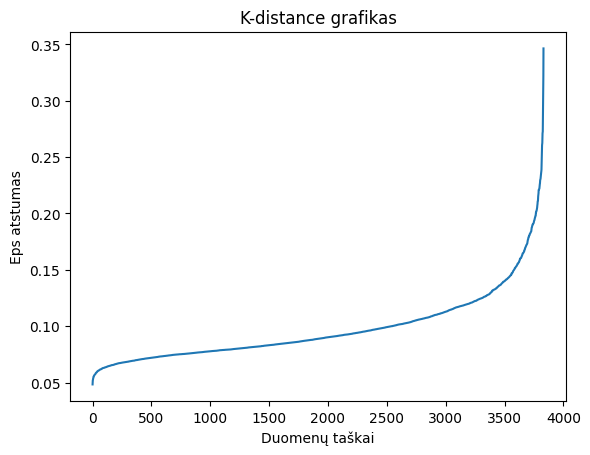

In [23]:
neighbors = NearestNeighbors(n_neighbors=8)
neighbors_fit = neighbors.fit(variance_subset)
distances, indices = neighbors_fit.kneighbors(variance_subset)

distances = np.sort(distances[:, 7], axis=0)
plt.plot(distances)
plt.title('K-distance grafikas')
plt.xlabel('Duomenų taškai')
plt.ylabel('Eps atstumas')
plt.show()

In [24]:
dbscan = DBSCAN(eps=0.15, min_samples=8)
clusters = dbscan.fit_predict(variance_subset)

dbscan_clusters = variance_subset.copy()
dbscan_clusters['cluster'] = clusters

print(dbscan_clusters['cluster'].value_counts())

cluster
 0    3734
-1      98
Name: count, dtype: int64


In [27]:
tsne = TSNE(n_components=2, random_state=42, perplexity=50, learning_rate=500, max_iter=2000, early_exaggeration=4)
tsne_results = tsne.fit_transform(dbscan_clusters.drop(columns=['cluster']))

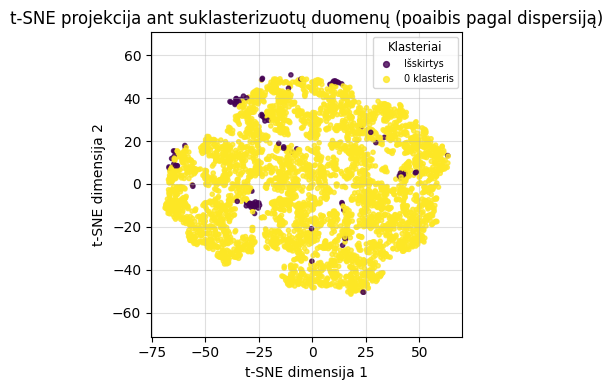

In [29]:
tsne_df = pd.DataFrame(tsne_results, columns=['tsne_1', 'tsne_2'])
plt.figure(figsize=(4, 4))
scatter = plt.scatter(tsne_df['tsne_1'], 
                      tsne_df['tsne_2'], alpha=0.8, s=9, c=dbscan_clusters['cluster'],)

plt.title("t-SNE projekcija ant suklasterizuotų duomenų (poaibis pagal dispersiją)")
plt.xlabel("t-SNE dimensija 1")
plt.ylabel("t-SNE dimensija 2")

handles, _ = scatter.legend_elements()
unique_labels = np.unique(clusters)
label_names = [f'{int(l)} klasteris' if l != -1 else 'Išskirtys' for l in unique_labels]
plt.legend(handles, label_names, 
           title="Klasteriai", 
           fontsize='x-small',
           title_fontsize='small',
           markerscale=0.7)
plt.grid(alpha=0.4)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [30]:
tsne = TSNE(n_components=2, random_state=42, perplexity=50, learning_rate=500, max_iter=2000, early_exaggeration=4)
tsne_results = tsne.fit_transform(variance_subset)

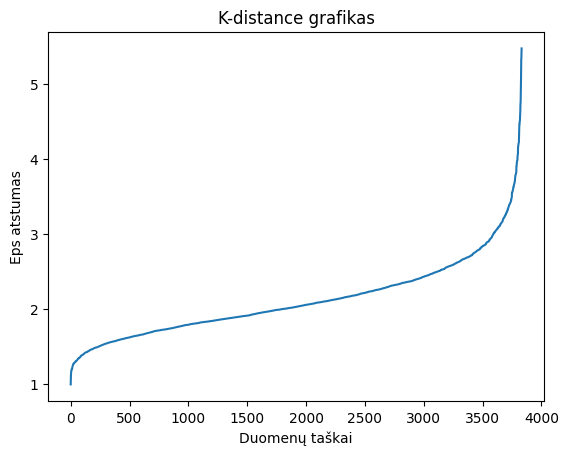

In [31]:
neighbors = NearestNeighbors(n_neighbors=8)
neighbors_fit = neighbors.fit(tsne_results)
distances, indices = neighbors_fit.kneighbors(tsne_results)

distances = np.sort(distances[:, 7], axis=0)
plt.plot(distances)
plt.title('K-distance grafikas')
plt.xlabel('Duomenų taškai')
plt.ylabel('Eps atstumas')
plt.show()

In [33]:
dbscan_tsne = DBSCAN(eps=3, min_samples=8)
clusters_tsne = dbscan_tsne.fit_predict(tsne_results)

dbscan_clusters_tsne = pd.DataFrame(tsne_results, columns=['tsne_1', 'tsne_2'])
dbscan_clusters_tsne['cluster'] = clusters_tsne
print(dbscan_clusters_tsne['cluster'].value_counts())

cluster
 0    3768
-1      47
 1       9
 2       8
Name: count, dtype: int64


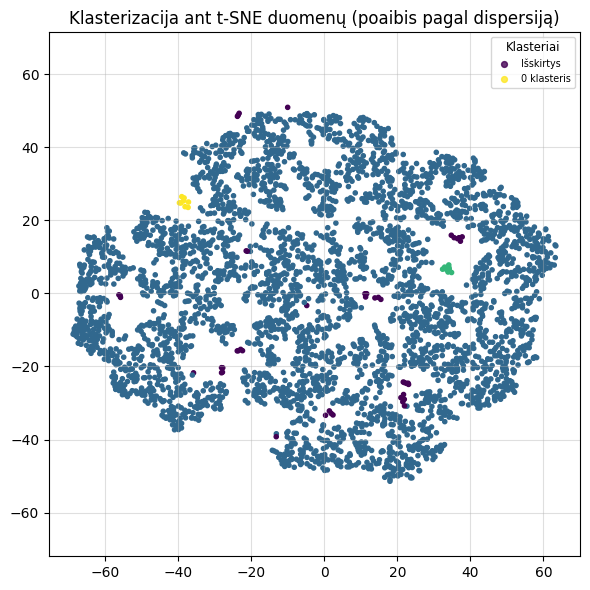

In [37]:
plt.figure(figsize=(6, 6))
plt.scatter(dbscan_clusters_tsne['tsne_1'], 
            dbscan_clusters_tsne['tsne_2'], 
            c=dbscan_clusters_tsne['cluster'], 
            cmap='viridis', s=9)
plt.title("Klasterizacija ant t-SNE duomenų (poaibis pagal dispersiją)")

handles, _ = scatter.legend_elements()
unique_labels = np.unique(clusters)
label_names = [f'{int(l)} klasteris' if l != -1 else 'Išskirtys' for l in unique_labels]
plt.legend(handles, label_names, 
           title="Klasteriai", 
           fontsize='x-small',
           title_fontsize='small',
           markerscale=0.7)
plt.grid(alpha=0.4)
plt.axis('equal')
plt.tight_layout()
plt.show()